# Correlation & Feature Analysis — 50 Indian Cities

This notebook performs correlation analysis, finds redundant features, checks target relevance, measures multicollinearity with VIF, and prepares final feature recommendations using 50 city files from the Kaggle weather dataset.

Dataset: https://www.kaggle.com/datasets/mukeshdevrath007/indian-5000-cities-weather-data

In [1]:
import os
import re
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

SAVE = "/kaggle/working/correlation_feature_50_cities/"
os.makedirs(SAVE, exist_ok=True)

print("Setup complete")

Setup complete


## Step 1 — Find Kaggle CSV files

In [2]:
INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise FileNotFoundError("Run this notebook inside Kaggle.")

csv_files = sorted([
    str(file) for file in INPUT_ROOT.rglob("*")
    if file.is_file() and (
        file.name.lower().endswith(".csv") or
        file.name.lower().endswith(".csv.gz")
    )
])

if not csv_files:
    raise FileNotFoundError(
        "No CSV files found. Attach the weather dataset using Add Input."
    )

print(f"CSV files found: {len(csv_files):,}")
print("First file:", csv_files[0])

CSV files found: 4,686
First file: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis/weather.csv


## Step 2 — Prepare the same deterministic 50-city selection

In [3]:
def normalize_name(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


def get_dataset_city_name(file_path):
    path = Path(file_path)
    name = path.name[:-7] if path.name.lower().endswith(".csv.gz") else path.stem
    generic = {"weather", "weatherdata", "hourlyweather", "data"}
    return path.parent.name if normalize_name(name) in generic else name


available_files = pd.DataFrame({
    "city": [get_dataset_city_name(file) for file in csv_files],
    "file": csv_files,
})
available_files["city_key"] = available_files["city"].apply(normalize_name)

invalid_words = ["weatherdata", "scraping", "analysis", "readme", "metadata"]
available_files = available_files[
    ~available_files["city_key"].apply(
        lambda name: any(word in name for word in invalid_words)
    )
].drop_duplicates("city_key").sort_values("city").reset_index(drop=True)

PREFERRED_CITIES = [
    "Agartala", "Agra", "Ahmedabad", "Aizawl", "Amritsar",
    "Bhopal", "Chandigarh", "Chennai", "Coimbatore", "Cuttack",
    "Dehra Dun", "Delhi", "Guwahati", "Hyderabad", "Imphal",
    "Indore", "Itanagar", "Jaipur", "Jammu", "Jodhpur",
    "Kochi", "Kohima", "Kolkata", "Kota", "Leh",
    "Lucknow", "Ludhiana", "Mumbai", "Nagpur", "Patna",
    "Prayagraj", "Pune", "Raipur", "Rajkot", "Ranchi"
]
preferred_keys = {normalize_name(city) for city in PREFERRED_CITIES}
preferred = available_files[available_files["city_key"].isin(preferred_keys)]
remaining = available_files[
    ~available_files["city_key"].isin(preferred["city_key"])
].reset_index(drop=True)

# Extra candidates allow invalid non-weather CSVs to be skipped while loading 50 cities.
extra_needed = min(60, len(remaining))
indices = np.linspace(0, len(remaining) - 1, extra_needed, dtype=int)
candidate_files = pd.concat([preferred, remaining.iloc[indices]], ignore_index=True)

print("Preferred cities found:", len(preferred))
print("Candidate files prepared:", len(candidate_files))
display(candidate_files[["city", "file"]].head(50))

Preferred cities found: 35
Candidate files prepared: 95


,city,file
0,Agartala,/kaggle/input/datasets/mukeshdevrath007/indian...
1,Agra,/kaggle/input/datasets/mukeshdevrath007/indian...
2,Ahmedabad,/kaggle/input/datasets/mukeshdevrath007/indian...
3,Aizawl,/kaggle/input/datasets/mukeshdevrath007/indian...
4,Amritsar,/kaggle/input/datasets/mukeshdevrath007/indian...
5,Bhopal,/kaggle/input/datasets/mukeshdevrath007/indian...
6,Chandigarh,/kaggle/input/datasets/mukeshdevrath007/indian...
7,Chennai,/kaggle/input/datasets/mukeshdevrath007/indian...
8,Coimbatore,/kaggle/input/datasets/mukeshdevrath007/indian...
9,Cuttack,/kaggle/input/datasets/mukeshdevrath007/indian...


## Step 3 — Match raw weather columns and create daily features

In [4]:
COLUMN_ALIASES = {
    "time": ["time", "datetime", "date"],
    "temperature_2m": ["temperature2m", "temp2m", "temperature"],
    "relative_humidity_2m": ["relativehumidity2m", "humidity2m", "relativehumidity"],
    "dew_point_2m": ["dewpoint2m", "dewpoint"],
    "precipitation": ["precipitation", "precip"],
    "rain": ["rain"],
    "cloud_cover": ["cloudcover", "cloudiness"],
    "cloud_cover_low": ["cloudcoverlow", "lowcloudcover"],
    "cloud_cover_mid": ["cloudcovermid", "midcloudcover"],
    "cloud_cover_high": ["cloudcoverhigh", "highcloudcover"],
    "wind_speed_10m": ["windspeed10m", "wind10m"],
    "wind_speed_100m": ["windspeed100m", "wind100m"],
    "wind_gusts_10m": ["windgusts10m", "windgust10m", "windgusts"],
    "pressure_msl": ["pressuremsl", "sealevelpressure"],
    "surface_pressure": ["surfacepressure"],
}


def match_columns(columns):
    normalized = {column: normalize_name(column) for column in columns}
    matched = {}
    for standard, aliases in COLUMN_ALIASES.items():
        targets = [normalize_name(alias) for alias in aliases]
        exact = [column for column, name in normalized.items() if name in targets]
        prefix = [column for column, name in normalized.items()
                  if any(name.startswith(target) for target in targets)]
        if exact or prefix:
            matched[standard] = (exact or prefix)[0]
    return matched


def summarize_city(file, city):
    header = pd.read_csv(file, nrows=0).columns.tolist()
    matched = match_columns(header)
    if "time" not in matched or "temperature_2m" not in matched:
        raise ValueError("Required time or temperature column not found")

    raw = pd.read_csv(file, usecols=list(dict.fromkeys(matched.values())), low_memory=False)
    raw = raw.rename(columns={original: standard for standard, original in matched.items()})
    raw["datetime"] = pd.to_datetime(raw.pop("time"), errors="coerce", utc=True).dt.tz_localize(None)
    raw = raw.dropna(subset=["datetime"])
    if raw.empty:
        raise ValueError("No valid timestamps")

    for column in raw.columns.difference(["datetime"]):
        raw[column] = pd.to_numeric(raw[column], errors="coerce", downcast="float")

    raw["date"] = raw["datetime"].dt.floor("D")
    grouped = raw.groupby("date", sort=False)
    daily = pd.DataFrame(index=grouped.size().index)

    def add(source, outputs):
        if source in raw:
            for output, operation in outputs.items():
                daily[output] = grouped[source].agg(operation)

    add("temperature_2m", {"temp_mean": "mean", "temp_max": "max", "temp_min": "min"})
    add("relative_humidity_2m", {"humidity_mean": "mean"})
    add("dew_point_2m", {"dew_mean": "mean"})
    add("precipitation", {"precip_total": "sum", "precip_max": "max"})
    if "precip_total" not in daily:
        add("rain", {"precip_total": "sum", "precip_max": "max"})
    add("cloud_cover", {"cloud_mean": "mean"})
    add("cloud_cover_low", {"cloud_low_mean": "mean"})
    add("cloud_cover_mid", {"cloud_mid_mean": "mean"})
    add("cloud_cover_high", {"cloud_high_mean": "mean"})
    add("wind_speed_10m", {"wind_mean_10m": "mean", "wind_max_10m": "max"})
    add("wind_speed_100m", {
        "wind_mean_100m": "mean", "wind_max_100m": "max", "wind_std_100m": "std"
    })
    add("wind_gusts_10m", {"wind_gusts_max": "max"})
    add("pressure_msl", {"pressure_mean": "mean"})
    add("surface_pressure", {"surface_pressure_mean": "mean"})

    if "precip_total" in daily:
        daily["rain_occurred"] = (daily["precip_total"] > 0).astype("int8")

    daily = daily.reset_index()
    daily.insert(1, "city", city)
    del raw
    gc.collect()
    return daily, matched

In [ ]:
daily_frames = []
load_log = []

for _, row in candidate_files.iterrows():
    if len(daily_frames) >= 50:
        break
    try:
        city_daily, matched = summarize_city(row["file"], row["city"])
        daily_frames.append(city_daily)
        load_log.append({"city": row["city"], "status": "loaded",
                         "daily_rows": len(city_daily),
                         "matched_columns": len(matched), "error": ""})
    except Exception as error:
        load_log.append({"city": row["city"], "status": "skipped",
                         "daily_rows": 0, "matched_columns": 0,
                         "error": str(error)[:160]})

    if len(load_log) % 10 == 0:
        print(f"Checked {len(load_log)} files; loaded {len(daily_frames)}/50 cities")

load_log = pd.DataFrame(load_log)
display(load_log)

if len(daily_frames) < 50:
    raise RuntimeError(f"Only {len(daily_frames)} valid cities loaded. Review load_log.")

df = pd.concat(daily_frames, ignore_index=True)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("Final shape:", df.shape)
print("Cities loaded:", df["city"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

## Step 4 — Prepare numeric features

In [7]:
# Check that previous required cells were executed
required_objects = [
    "candidate_files",
    "summarize_city"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"Run the previous setup cells first. Missing: {missing_objects}"
    )


daily_frames = []
load_records = []
loaded_cities = set()


for _, row in candidate_files.iterrows():

    # Stop after loading 50 unique cities
    if len(loaded_cities) >= 50:
        break

    city = row["city"]
    file_path = row["file"]

    # Avoid duplicate cities
    if city in loaded_cities:
        continue

    try:
        city_daily, matched = summarize_city(
            file_path,
            city
        )

        if city_daily.empty:
            raise ValueError("No valid daily records were created")

        daily_frames.append(city_daily)
        loaded_cities.add(city)

        load_records.append({
            "city": city,
            "status": "loaded",
            "daily_rows": len(city_daily),
            "matched_columns": len(matched),
            "error": ""
        })

    except Exception as error:
        load_records.append({
            "city": city,
            "status": "skipped",
            "daily_rows": 0,
            "matched_columns": 0,
            "error": str(error)[:160]
        })

    if len(load_records) % 10 == 0:
        print(
            f"Checked {len(load_records)} files; "
            f"loaded {len(loaded_cities)}/50 cities"
        )


# Create load-status table
load_log = pd.DataFrame(load_records)
display(load_log)


# Stop only when no city was loaded
if not daily_frames:
    raise RuntimeError(
        "No city files were loaded. Check the error column in load_log."
    )


# Create the final combined dataframe
df = pd.concat(
    daily_frames,
    ignore_index=True
)


# Ensure correct data types
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df = df.dropna(subset=["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month


# Remove duplicate city-date records if present
duplicate_count = df.duplicated(
    subset=["city", "date"]
).sum()

if duplicate_count > 0:
    print("Duplicate city-date rows removed:", duplicate_count)

    df = df.drop_duplicates(
        subset=["city", "date"]
    ).reset_index(drop=True)


print("\nData loading completed")
print("Final shape  :", df.shape)
print("Cities loaded:", df["city"].nunique())
print(
    "Date range   :",
    df["date"].min().date(),
    "to",
    df["date"].max().date()
)


if df["city"].nunique() < 50:
    print(
        f"\nWarning: Only {df['city'].nunique()} valid cities were loaded. "
        "Review the skipped rows in load_log."
    )

Checked 10 files; loaded 10/50 cities
Checked 20 files; loaded 20/50 cities
Checked 30 files; loaded 30/50 cities
Checked 40 files; loaded 40/50 cities
Checked 50 files; loaded 50/50 cities


,city,status,daily_rows,matched_columns,error
0,Agartala,loaded,5164,15,
1,Agra,loaded,5164,15,
2,Ahmedabad,loaded,5164,15,
3,Aizawl,loaded,5164,15,
4,Amritsar,loaded,5164,15,
5,Bhopal,loaded,5164,15,
6,Chandigarh,loaded,5164,15,
7,Chennai,loaded,5164,15,
8,Coimbatore,loaded,5164,15,
9,Cuttack,loaded,5164,15,



Data loading completed
Final shape  : (258200, 24)
Cities loaded: 50
Date range   : 2010-01-01 to 2024-02-20


## Step 5 — Full Pearson correlation matrix

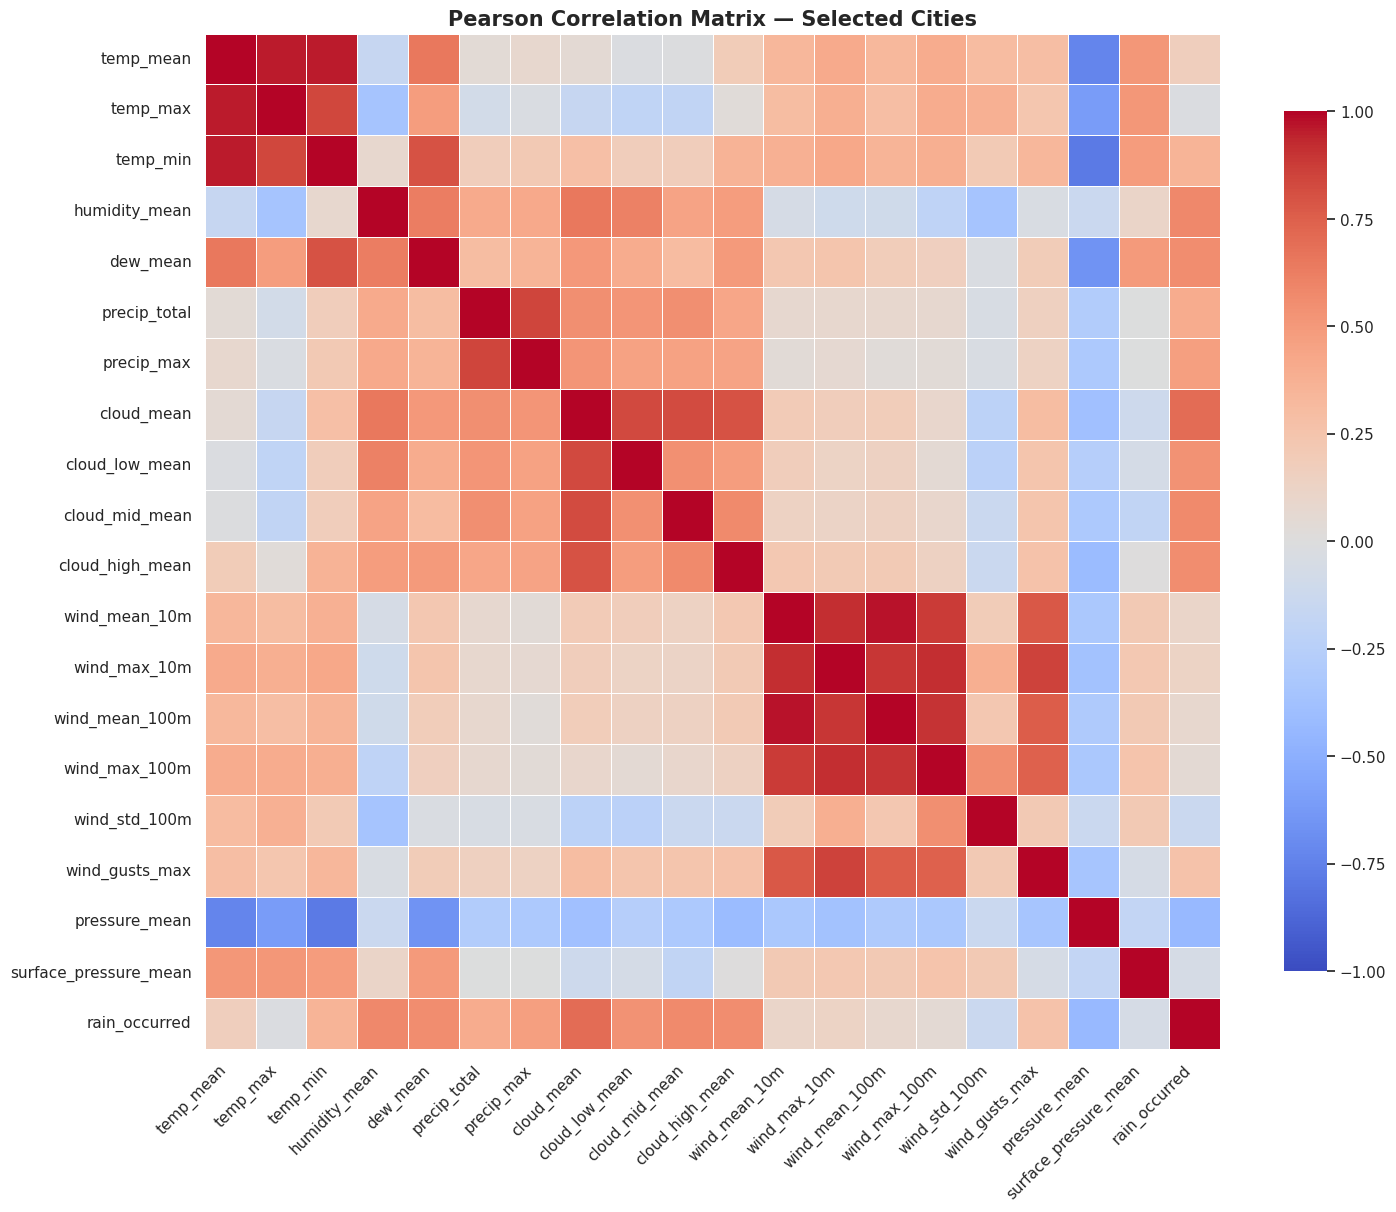

Pearson correlation completed
Features analyzed: 20
Saved: /kaggle/working/correlation_feature_50_cities/pearson_correlation_matrix.png


,temp_mean,temp_max,temp_min,humidity_mean,dew_mean,precip_total,precip_max,cloud_mean,cloud_low_mean,cloud_mid_mean,cloud_high_mean,wind_mean_10m,wind_max_10m,wind_mean_100m,wind_max_100m,wind_std_100m,wind_gusts_max,pressure_mean,surface_pressure_mean,rain_occurred
temp_mean,1.000,0.960,0.955,-0.160,0.655,0.044,0.085,0.053,-0.023,-0.012,0.191,0.344,0.413,0.328,0.402,0.307,0.290,-0.731,0.510,0.164
temp_max,0.960,1.000,0.843,-0.352,0.482,-0.080,-0.030,-0.162,-0.199,-0.193,0.026,0.303,0.385,0.294,0.400,0.382,0.239,-0.616,0.510,-0.016
temp_min,0.955,0.843,1.000,0.085,0.803,0.178,0.215,0.284,0.176,0.175,0.363,0.378,0.429,0.356,0.388,0.204,0.338,-0.785,0.485,0.354
humidity_mean,-0.160,-0.352,0.085,1.000,0.628,0.406,0.419,0.653,0.617,0.452,0.484,-0.061,-0.106,-0.097,-0.207,-0.358,-0.037,-0.138,0.113,0.585
dew_mean,0.655,0.482,0.803,0.628,1.000,0.304,0.352,0.501,0.405,0.305,0.499,0.228,0.246,0.186,0.159,-0.029,0.191,-0.658,0.493,0.555
precip_total,0.044,-0.080,0.178,0.406,0.304,1.000,0.845,0.555,0.518,0.550,0.436,0.077,0.082,0.081,0.073,-0.042,0.155,-0.288,-0.006,0.404
precip_max,0.085,-0.030,0.215,0.419,0.352,0.845,1.000,0.523,0.453,0.457,0.448,0.032,0.063,0.030,0.039,-0.037,0.135,-0.317,-0.005,0.473
cloud_mean,0.053,-0.162,0.284,0.653,0.501,0.555,0.523,1.000,0.829,0.822,0.802,0.203,0.173,0.181,0.089,-0.222,0.303,-0.386,-0.109,0.702
cloud_low_mean,-0.023,-0.199,0.176,0.617,0.405,0.518,0.453,0.829,1.000,0.546,0.479,0.174,0.131,0.146,0.050,-0.227,0.250,-0.259,-0.064,0.539
cloud_mid_mean,-0.012,-0.193,0.175,0.452,0.305,0.550,0.457,0.822,0.546,1.000,0.573,0.139,0.121,0.144,0.090,-0.137,0.244,-0.313,-0.191,0.578


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Check whether the data-loading cell was executed
if "df" not in globals():
    raise RuntimeError(
        "df is not available. Run the city-loading cell first."
    )

if df is None or df.empty:
    raise RuntimeError(
        "df is empty. Check the load_log table."
    )


# Automatically identify numeric weather columns if required
if "NUMERIC_COLS" not in globals() or not NUMERIC_COLS:

    excluded_columns = {
        "year",
        "month"
    }

    NUMERIC_COLS = [
        column
        for column in df.select_dtypes(include=np.number).columns
        if column not in excluded_columns
        and df[column].nunique(dropna=True) > 1
    ]


# Keep only columns that are actually available
valid_numeric_cols = [
    column
    for column in NUMERIC_COLS
    if column in df.columns
]


if len(valid_numeric_cols) < 2:
    raise RuntimeError(
        "At least two valid numeric features are required "
        "for correlation analysis."
    )


# Convert selected columns to numeric
correlation_data = df[valid_numeric_cols].copy()

for column in valid_numeric_cols:
    correlation_data[column] = pd.to_numeric(
        correlation_data[column],
        errors="coerce"
    )


# Replace infinite values
correlation_data = correlation_data.replace(
    [np.inf, -np.inf],
    np.nan
)


# Remove completely empty columns
correlation_data = correlation_data.dropna(
    axis=1,
    how="all"
)


# Calculate Pearson correlation
pearson_corr = correlation_data.corr(
    method="pearson",
    min_periods=30
)


if pearson_corr.empty:
    raise RuntimeError(
        "Pearson correlation could not be calculated."
    )


# Create output directory
SAVE = "/kaggle/working/correlation_feature_50_cities/"
os.makedirs(SAVE, exist_ok=True)


# Plot correlation heatmap
figure_width = max(
    13,
    len(pearson_corr.columns) * 0.75
)

figure_height = max(
    10,
    len(pearson_corr.columns) * 0.65
)


plt.figure(
    figsize=(figure_width, figure_height)
)

sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=len(pearson_corr.columns) <= 18,
    fmt=".2f",
    square=True,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"shrink": 0.75}
)

plt.title(
    "Pearson Correlation Matrix — Selected Cities",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

output_path = os.path.join(
    SAVE,
    "pearson_correlation_matrix.png"
)

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print("Pearson correlation completed")
print("Features analyzed:", len(pearson_corr.columns))
print("Saved:", output_path)

display(pearson_corr)

## Step 6 — Spearman correlation for non-linear or skewed variables

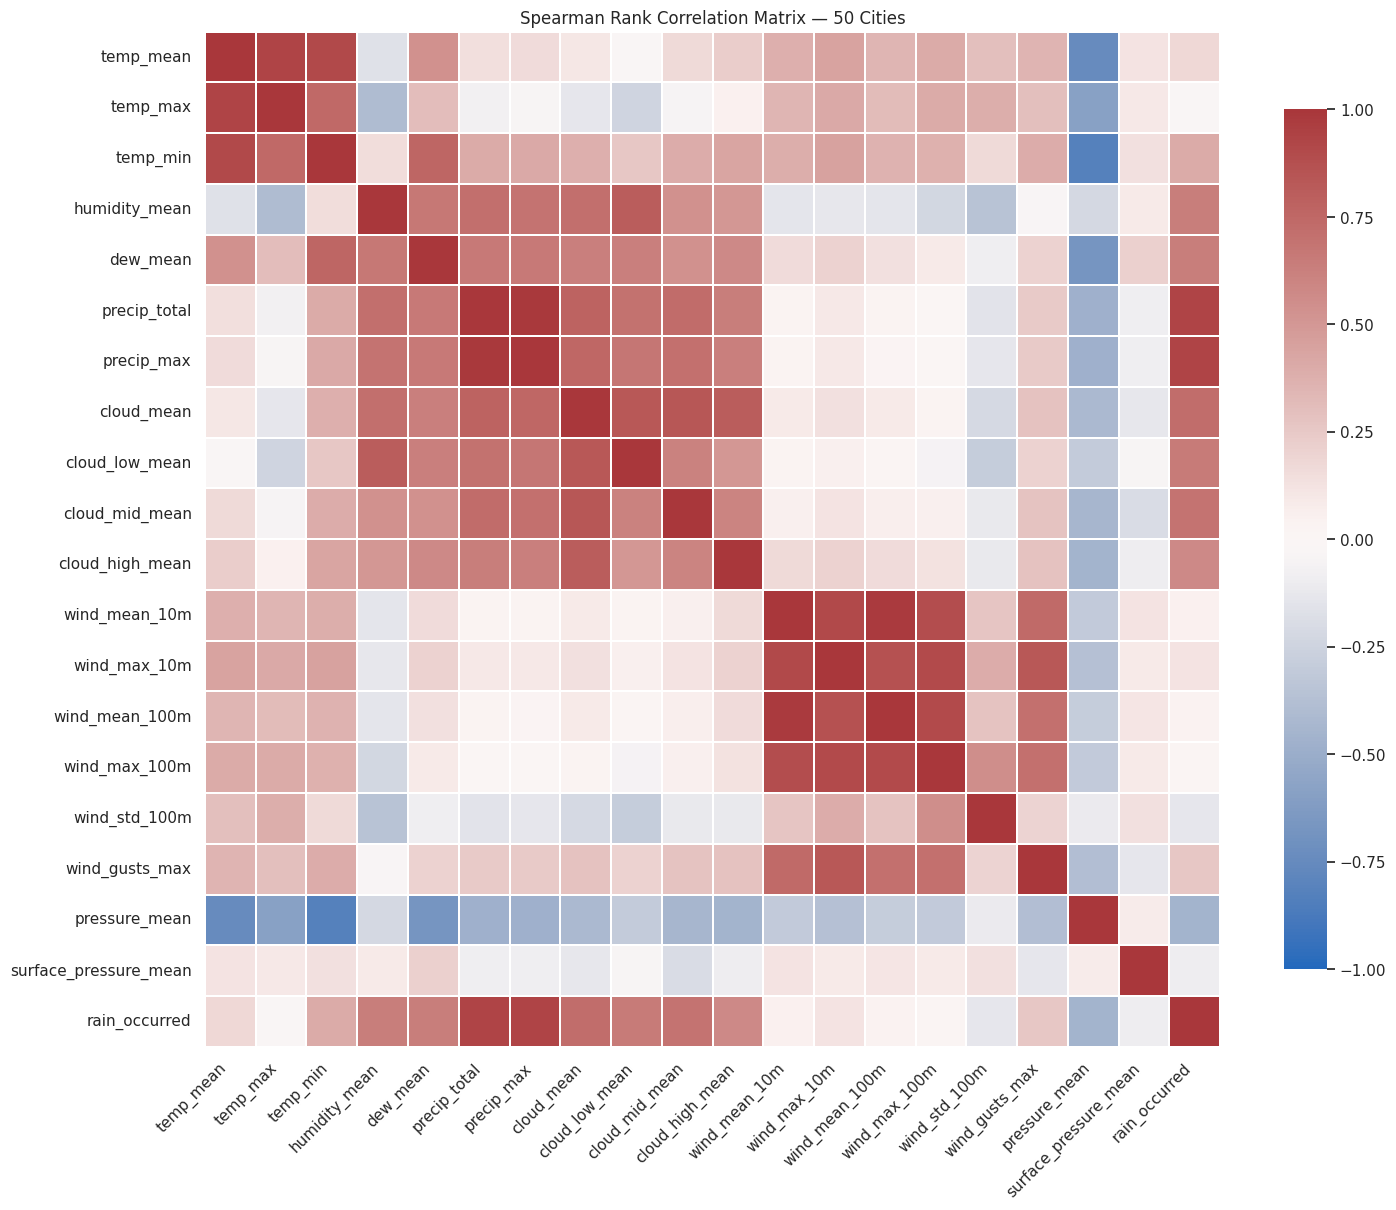

In [10]:
spearman_corr = df[NUMERIC_COLS].corr(method="spearman")

plt.figure(figsize=(max(13, len(NUMERIC_COLS) * 0.75),
                    max(10, len(NUMERIC_COLS) * 0.65)))
sns.heatmap(
    spearman_corr, cmap="vlag", center=0, vmin=-1, vmax=1,
    annot=False, square=True, linewidths=0.3,
    cbar_kws={"shrink": 0.75}
)
plt.title("Spearman Rank Correlation Matrix — 50 Cities")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(SAVE + "spearman_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7 — High-correlation and redundant feature pairs

In [11]:
pair_rows = []
for i, first in enumerate(NUMERIC_COLS):
    for second in NUMERIC_COLS[i + 1:]:
        pearson_value = pearson_corr.loc[first, second]
        spearman_value = spearman_corr.loc[first, second]
        if abs(pearson_value) >= 0.80 or abs(spearman_value) >= 0.80:
            maximum = max(abs(pearson_value), abs(spearman_value))
            pair_rows.append({
                "feature_1": first, "feature_2": second,
                "pearson": pearson_value, "spearman": spearman_value,
                "max_absolute_correlation": maximum,
                "decision": "DROP ONE — near duplicate" if maximum >= 0.95 else
                            "WATCH — multicollinearity risk"
            })

high_correlation_pairs = (pd.DataFrame(pair_rows)
                          .sort_values("max_absolute_correlation", ascending=False)
                          if pair_rows else pd.DataFrame(columns=[
                              "feature_1", "feature_2", "pearson", "spearman",
                              "max_absolute_correlation", "decision"
                          ]))
display(high_correlation_pairs)

,feature_1,feature_2,pearson,spearman,max_absolute_correlation,decision
6,precip_total,precip_max,0.845,0.991,0.991,DROP ONE — near duplicate
13,wind_mean_10m,wind_mean_100m,0.977,0.977,0.977,DROP ONE — near duplicate
0,temp_mean,temp_max,0.960,0.933,0.960,DROP ONE — near duplicate
1,temp_mean,temp_min,0.955,0.913,0.955,DROP ONE — near duplicate
8,precip_max,rain_occurred,0.473,0.936,0.936,WATCH — multicollinearity risk
7,precip_total,rain_occurred,0.404,0.936,0.936,WATCH — multicollinearity risk
16,wind_max_10m,wind_max_100m,0.919,0.901,0.919,WATCH — multicollinearity risk
12,wind_mean_10m,wind_max_10m,0.915,0.911,0.915,WATCH — multicollinearity risk
18,wind_mean_100m,wind_max_100m,0.904,0.904,0.904,WATCH — multicollinearity risk
15,wind_max_10m,wind_mean_100m,0.892,0.874,0.892,WATCH — multicollinearity risk


## Step 8 — Feature relevance for important targets

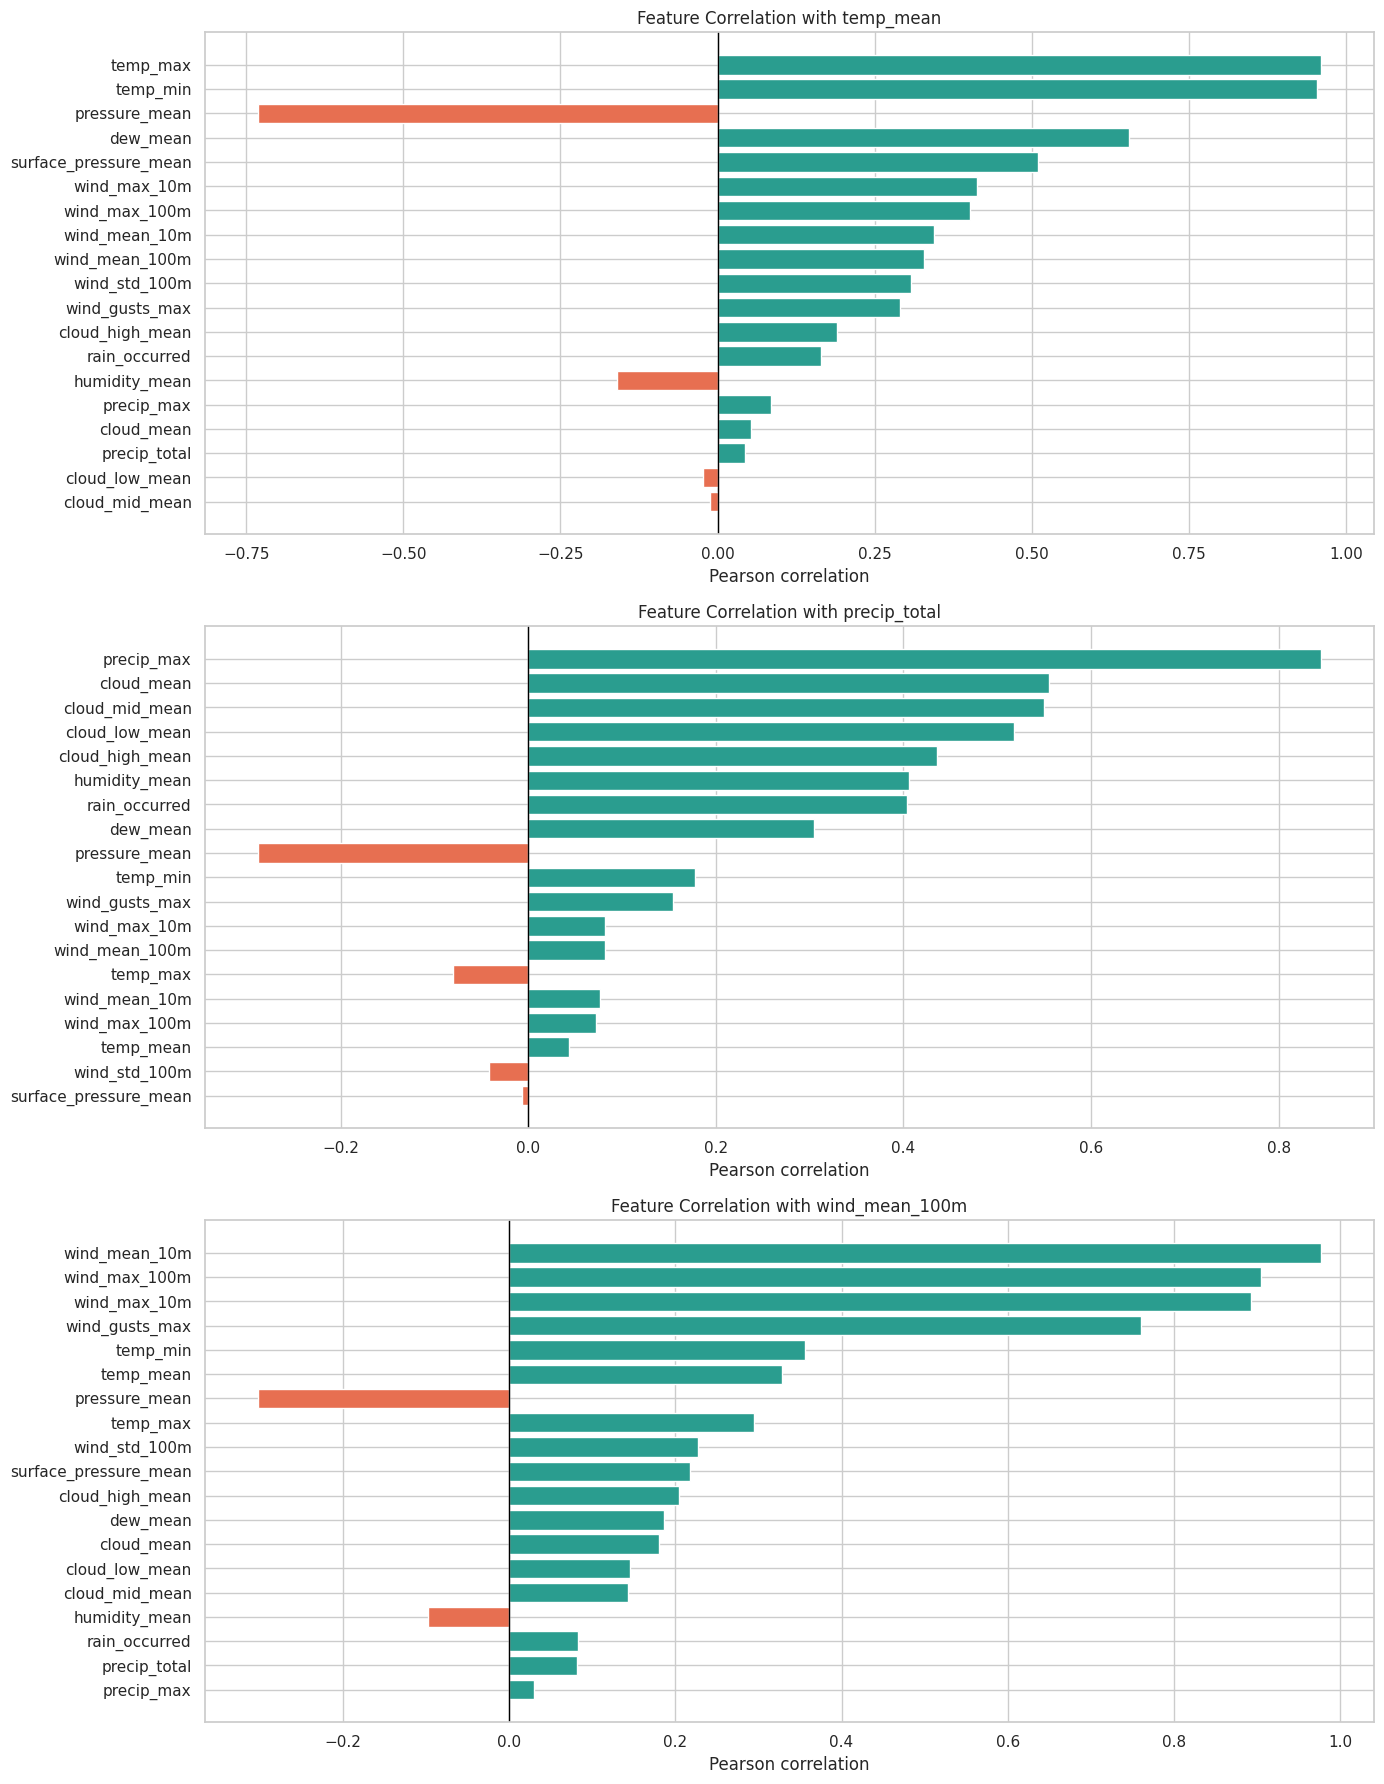

,target,feature,pearson_correlation,absolute_correlation
19,precip_total,precip_max,0.845,0.845
20,precip_total,cloud_mean,0.555,0.555
21,precip_total,cloud_mid_mean,0.550,0.550
22,precip_total,cloud_low_mean,0.518,0.518
23,precip_total,cloud_high_mean,0.436,0.436
24,precip_total,humidity_mean,0.406,0.406
25,precip_total,rain_occurred,0.404,0.404
26,precip_total,dew_mean,0.304,0.304
27,precip_total,pressure_mean,-0.288,0.288
28,precip_total,temp_min,0.178,0.178


In [12]:
TARGETS = [target for target in ["temp_mean", "precip_total", "wind_mean_100m"]
           if target in NUMERIC_COLS]

target_correlations = []
fig, axes = plt.subplots(len(TARGETS), 1, figsize=(14, 6 * len(TARGETS)), squeeze=False)

for ax, target in zip(axes.flat, TARGETS):
    values = (pearson_corr[target].drop(target)
              .sort_values(key=lambda series: series.abs(), ascending=False))
    for feature, correlation in values.items():
        target_correlations.append({
            "target": target, "feature": feature,
            "pearson_correlation": correlation,
            "absolute_correlation": abs(correlation)
        })

    colors = np.where(values >= 0, "#2a9d8f", "#e76f51")
    ax.barh(values.index[::-1], values.values[::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Feature Correlation with " + target)
    ax.set_xlabel("Pearson correlation")

plt.tight_layout()
plt.savefig(SAVE + "target_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

target_correlation_df = pd.DataFrame(target_correlations)
display(target_correlation_df.sort_values(["target", "absolute_correlation"],
                                          ascending=[True, False]))

## Step 9 — Clustering feature independence

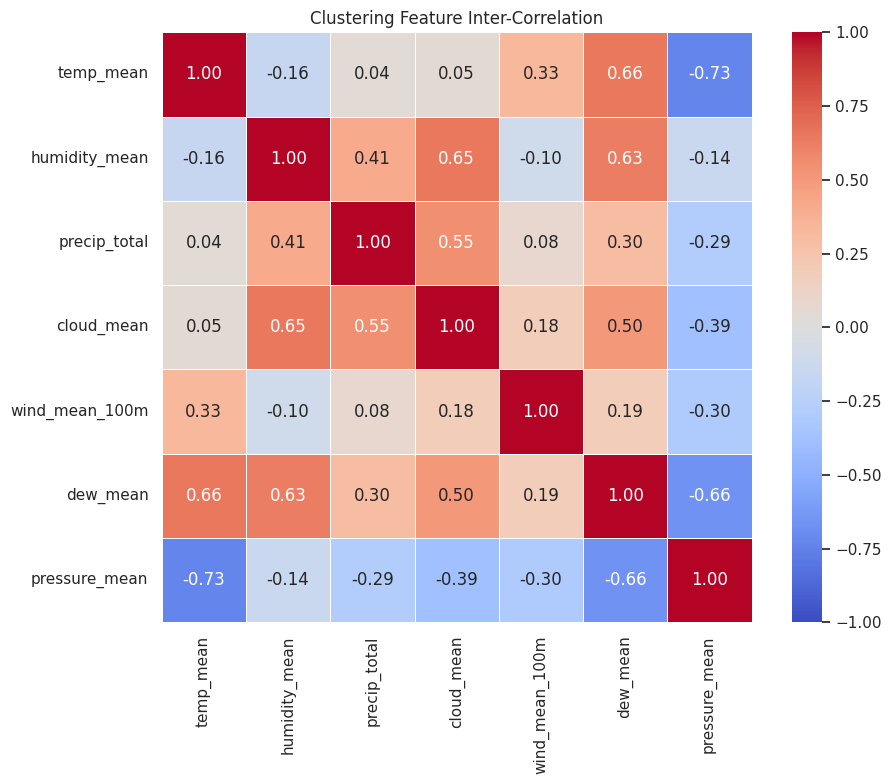

No clustering feature pair has |correlation| >= 0.80.


In [13]:
CLUSTER_FEATURES = [column for column in [
    "temp_mean", "humidity_mean", "precip_total", "cloud_mean",
    "wind_mean_100m", "dew_mean", "pressure_mean"
] if column in NUMERIC_COLS]

cluster_corr = df[CLUSTER_FEATURES].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(cluster_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Clustering Feature Inter-Correlation")
plt.tight_layout()
plt.savefig(SAVE + "clustering_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

cluster_high_pairs = []
for i, first in enumerate(CLUSTER_FEATURES):
    for second in CLUSTER_FEATURES[i + 1:]:
        value = cluster_corr.loc[first, second]
        if abs(value) >= 0.80:
            cluster_high_pairs.append({"feature_1": first, "feature_2": second,
                                       "correlation": value, "status": "REVIEW"})

cluster_independence_report = pd.DataFrame(cluster_high_pairs)
if cluster_independence_report.empty:
    print("No clustering feature pair has |correlation| >= 0.80.")
else:
    display(cluster_independence_report)

## Step 10 — Variance Inflation Factor (VIF)

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

VIF_FEATURES = [column for column in [
    "humidity_mean", "dew_mean", "pressure_mean", "cloud_mean",
    "wind_mean_100m", "wind_gusts_max", "precip_total", "temp_mean"
] if column in NUMERIC_COLS]

vif_data = df[VIF_FEATURES].replace([np.inf, -np.inf], np.nan).dropna()
if len(vif_data) > 100000:
    vif_data = vif_data.sample(100000, random_state=42)

vif_with_constant = add_constant(vif_data, has_constant="add")
vif_rows = []
for index, feature in enumerate(vif_with_constant.columns):
    if feature == "const":
        continue
    value = variance_inflation_factor(vif_with_constant.values, index)
    vif_rows.append({
        "feature": feature, "VIF": value,
        "flag": "DROP/REVIEW — severe" if value > 10 else
                "WATCH" if value > 5 else "OK"
    })

vif_report = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
display(vif_report)

,feature,VIF,flag
1,dew_mean,55.759,DROP/REVIEW — severe
0,humidity_mean,37.460,DROP/REVIEW — severe
7,temp_mean,36.636,DROP/REVIEW — severe
2,pressure_mean,2.998,OK
3,cloud_mean,2.800,OK
5,wind_gusts_max,2.679,OK
4,wind_mean_100m,2.515,OK
6,precip_total,1.507,OK


## Step 11 — Mutual information for non-linear target relevance

In [15]:
from sklearn.feature_selection import mutual_info_regression

mi_rows = []
for target in TARGETS:
    features = [column for column in NUMERIC_COLS if column != target]
    usable = df[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(usable) > 50000:
        usable = usable.sample(50000, random_state=42)
    if len(usable) < 100:
        continue

    scores = mutual_info_regression(
        usable[features], usable[target], random_state=42
    )
    for feature, score in zip(features, scores):
        mi_rows.append({"target": target, "feature": feature,
                        "mutual_information": score})

mutual_information_report = pd.DataFrame(mi_rows)
if not mutual_information_report.empty:
    display(mutual_information_report.sort_values(
        ["target", "mutual_information"], ascending=[True, False]
    ))

,target,feature,mutual_information
24,precip_total,precip_max,1.230
37,precip_total,rain_occurred,0.694
25,precip_total,cloud_mean,0.503
22,precip_total,humidity_mean,0.446
27,precip_total,cloud_mid_mean,0.423
26,precip_total,cloud_low_mean,0.361
23,precip_total,dew_mean,0.322
28,precip_total,cloud_high_mean,0.306
21,precip_total,temp_min,0.215
35,precip_total,pressure_mean,0.182


## Step 12 — Final feature recommendation table

In [17]:
import numpy as np
import pandas as pd


# Check required dataframe
if "df" not in globals() or df is None or df.empty:
    raise RuntimeError(
        "df is unavailable. Run the city-loading cell first."
    )


# Create NUMERIC_COLS if it is unavailable
if "NUMERIC_COLS" not in globals() or not NUMERIC_COLS:

    NUMERIC_COLS = [
        column
        for column in df.select_dtypes(include=np.number).columns
        if column not in ["year", "month"]
        and df[column].nunique(dropna=True) > 1
    ]


# Keep only existing and usable features
valid_features = [
    column
    for column in NUMERIC_COLS
    if column in df.columns
    and df[column].nunique(dropna=True) > 1
]


if len(valid_features) < 2:
    raise RuntimeError(
        "At least two usable numeric features are required."
    )


# Convert features to numeric
for column in valid_features:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# ---------------------------------------------------------
# 1. Create feature-quality table
# ---------------------------------------------------------

feature_quality = pd.DataFrame({
    "feature": valid_features,

    "missing_count": [
        df[column].isna().sum()
        for column in valid_features
    ],

    "missing_pct": [
        round(df[column].isna().mean() * 100, 2)
        for column in valid_features
    ],

    "unique_values": [
        df[column].nunique(dropna=True)
        for column in valid_features
    ],

    "variance": [
        df[column].var()
        for column in valid_features
    ]
})


# ---------------------------------------------------------
# 2. Calculate Pearson correlation if not available
# ---------------------------------------------------------

correlation_data = (
    df[valid_features]
    .replace([np.inf, -np.inf], np.nan)
)

pearson_corr = correlation_data.corr(
    method="pearson",
    min_periods=30
)


# Remove self-correlation values
maximum_corr = pearson_corr.abs().copy()

np.fill_diagonal(
    maximum_corr.values,
    np.nan
)


max_corr_by_feature = maximum_corr.max(axis=1)
max_partner = maximum_corr.idxmax(axis=1)


# ---------------------------------------------------------
# 3. Prepare VIF values
# ---------------------------------------------------------

# If the VIF cell was not executed, use blank VIF values
if (
    "vif_report" not in globals()
    or vif_report is None
    or vif_report.empty
    or "feature" not in vif_report.columns
    or "VIF" not in vif_report.columns
):
    vif_map = {}

    print(
        "Note: VIF report is unavailable. "
        "Correlation recommendations will still be generated."
    )

else:
    vif_map = dict(
        zip(
            vif_report["feature"],
            vif_report["VIF"]
        )
    )


# ---------------------------------------------------------
# 4. Build final feature report
# ---------------------------------------------------------

final_feature_report = feature_quality.copy()

final_feature_report["max_abs_correlation"] = (
    final_feature_report["feature"]
    .map(max_corr_by_feature)
)

final_feature_report["most_correlated_with"] = (
    final_feature_report["feature"]
    .map(max_partner)
)

final_feature_report["VIF"] = (
    final_feature_report["feature"]
    .map(vif_map)
)


# ---------------------------------------------------------
# 5. Generate recommendation
# ---------------------------------------------------------

def recommendation(row):

    if row["missing_pct"] > 30:
        return "REVIEW — high missingness"

    if row["unique_values"] <= 1:
        return "DROP — constant feature"

    if pd.isna(row["variance"]) or row["variance"] == 0:
        return "DROP — zero variance"

    if row["max_abs_correlation"] >= 0.95:
        return "REVIEW — near duplicate"

    if pd.notna(row["VIF"]) and row["VIF"] > 10:
        return "REVIEW — severe multicollinearity"

    if pd.notna(row["VIF"]) and row["VIF"] > 5:
        return "WATCH — high VIF"

    if row["max_abs_correlation"] >= 0.80:
        return "WATCH — correlated"

    return "KEEP"


final_feature_report["recommendation"] = (
    final_feature_report.apply(
        recommendation,
        axis=1
    )
)


# Define logical sorting order
recommendation_order = {
    "DROP — constant feature": 1,
    "DROP — zero variance": 1,
    "REVIEW — high missingness": 2,
    "REVIEW — near duplicate": 2,
    "REVIEW — severe multicollinearity": 2,
    "WATCH — high VIF": 3,
    "WATCH — correlated": 3,
    "KEEP": 4
}

final_feature_report["sort_order"] = (
    final_feature_report["recommendation"]
    .map(recommendation_order)
)


final_feature_report = (
    final_feature_report
    .sort_values(
        ["sort_order", "max_abs_correlation"],
        ascending=[True, False]
    )
    .drop(columns="sort_order")
    .reset_index(drop=True)
)


print("Final feature analysis completed")
print("\nRecommendation summary:")

display(
    final_feature_report["recommendation"]
    .value_counts()
    .to_frame("feature_count")
)

display(final_feature_report)

Final feature analysis completed

Recommendation summary:


,feature_count
recommendation,
WATCH — correlated,9
REVIEW — near duplicate,5
KEEP,4
REVIEW — severe multicollinearity,2


,feature,missing_count,missing_pct,unique_values,variance,max_abs_correlation,most_correlated_with,VIF,recommendation
0,wind_mean_10m,0,0.000,248564,19.129,0.977,wind_mean_100m,NaN,REVIEW — near duplicate
1,wind_mean_100m,0,0.000,248734,47.686,0.977,wind_mean_10m,2.515,REVIEW — near duplicate
2,temp_mean,0,0.000,150307,41.633,0.960,temp_max,36.636,REVIEW — near duplicate
3,temp_max,0,0.000,25779,42.358,0.960,temp_mean,NaN,REVIEW — near duplicate
4,temp_min,0,0.000,24550,48.795,0.955,temp_mean,NaN,REVIEW — near duplicate
5,dew_mean,0,0.000,156258,56.573,0.803,temp_min,55.759,REVIEW — severe multicollinearity
6,humidity_mean,0,0.000,253646,347.840,0.653,cloud_mean,37.460,REVIEW — severe multicollinearity
7,wind_max_10m,0,0.000,3312,32.306,0.919,wind_max_100m,NaN,WATCH — correlated
8,wind_max_100m,0,0.000,6019,64.021,0.919,wind_max_10m,NaN,WATCH — correlated
9,wind_gusts_max,0,0.000,235,103.993,0.853,wind_max_10m,2.679,WATCH — correlated


## Step 13 — Export results

In [18]:
df.to_csv(SAVE + "weather_50_cities_daily.csv", index=False)
load_log.to_csv(SAVE + "load_log.csv", index=False)
feature_quality.to_csv(SAVE + "feature_quality.csv", index=False)
pearson_corr.to_csv(SAVE + "pearson_correlation.csv")
spearman_corr.to_csv(SAVE + "spearman_correlation.csv")
high_correlation_pairs.to_csv(SAVE + "high_correlation_pairs.csv", index=False)
target_correlation_df.to_csv(SAVE + "target_feature_correlations.csv", index=False)
cluster_independence_report.to_csv(SAVE + "clustering_feature_independence.csv", index=False)
vif_report.to_csv(SAVE + "vif_report.csv", index=False)
mutual_information_report.to_csv(SAVE + "mutual_information_report.csv", index=False)
final_feature_report.to_csv(SAVE + "final_feature_recommendations.csv", index=False)

print("All results saved in:", SAVE)
print("Download them from the Kaggle Output panel after execution.")

All results saved in: /kaggle/working/correlation_feature_50_cities/
Download them from the Kaggle Output panel after execution.


## Interpretation notes

- Pearson correlation measures linear relationships.
- Spearman correlation measures monotonic relationships and is useful for skewed weather variables.
- Correlation does not prove causation.
- Near-duplicate features should be reviewed together; do not automatically delete both.
- VIF above 5 needs attention and VIF above 10 indicates severe multicollinearity.
- Mutual information can detect relationships that ordinary correlation may miss.